# Previsione della domanda oraria di bike sharing a Seoul

**Progetto d'esame — Programmazione di Applicazioni Data Intensive**

Autore: Nicolas Mancini — matricola 0001117661 — nicolas.mancini@studio.unibo.it

## 1. Contesto e obiettivo

I sistemi di *bike sharing* mettono a disposizione biciclette a noleggio distribuite in stazioni sparse per la città. Per garantire un buon servizio, il gestore deve assicurarsi che in ogni momento ci sia un numero adeguato di biciclette disponibili: troppe poche causano disservizi agli utenti, troppe generano costi inutili di gestione e ridistribuzione. Poter **prevedere quante biciclette verranno noleggiate in una certa ora** è quindi un'informazione preziosa per pianificare la ridistribuzione dei mezzi e il dimensionamento della flotta.

L'obiettivo di questo progetto è addestrare e confrontare diversi **modelli di regressione** che stimino il numero di biciclette noleggiate in un'ora dal sistema di bike sharing di Seoul (*Ddareungi*), a partire da informazioni temporali (ora, giorno, stagione, festività) e meteorologiche (temperatura, umidità, pioggia, ecc.).

### Il dataset

Il dataset utilizzato è **[Seoul Bike Sharing Demand](https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand)**, pubblicato sull'UCI Machine Learning Repository (licenza CC BY 4.0) e introdotto nei lavori di Sathishkumar V E et al. (*Computer Communications*, 2020; *European Journal of Remote Sensing*, 2020).

Contiene **8.760 istanze**: una per ogni ora dell'anno dal 1° dicembre 2017 al 30 novembre 2018 (365 giorni × 24 ore). Ogni istanza è descritta da **14 variabili**:

| Variabile | Tipo | Descrizione |
|---|---|---|
| `Date` | data (gg/mm/aaaa) | giorno dell'osservazione |
| `Rented Bike Count` | intero | **variabile target**: biciclette noleggiate nell'ora |
| `Hour` | intero (0–23) | ora del giorno |
| `Temperature(°C)` | continua | temperatura dell'aria |
| `Humidity(%)` | intero | umidità relativa |
| `Wind speed (m/s)` | continua | velocità del vento |
| `Visibility (10m)` | intero | visibilità (in decine di metri, max 2000) |
| `Dew point temperature(°C)` | continua | temperatura di rugiada |
| `Solar Radiation (MJ/m2)` | continua | radiazione solare |
| `Rainfall(mm)` | continua | pioggia caduta nell'ora |
| `Snowfall (cm)` | continua | neve caduta nell'ora |
| `Seasons` | categorica | stagione (Winter/Spring/Summer/Autumn) |
| `Holiday` | categorica | giorno festivo o no |
| `Functioning Day` | categorica | servizio attivo o no in quell'ora |

Non sono presenti identificatori o variabili palesemente non informative da scartare a priori; l'unica variabile che non useremo direttamente come predittore è `Date`, dalla quale però **estrarremo nuove variabili** (mese, giorno della settimana) nella fase di preparazione dei dati.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import xgboost

sns.set_theme(style="whitegrid", palette="deep")
RANDOM_STATE = 1117661   # seed fissato per riproducibilità
np.random.seed(RANDOM_STATE % 2**32)

print("numpy", np.__version__, "| pandas", pd.__version__,
      "| scikit-learn", sklearn.__version__, "| xgboost", xgboost.__version__)

numpy 2.4.6 | pandas 3.0.3 | scikit-learn 1.9.0 | xgboost 3.2.0


Scarichiamo il dataset direttamente dall'UCI Machine Learning Repository (se non già presente in locale) e carichiamolo in un DataFrame. Il file usa la codifica `cp1252` (contiene il simbolo `°` nei nomi delle colonne); per comodità rinominiamo subito le colonne con nomi brevi e uniformi.

In [2]:
import os, zipfile, urllib.request

URL = "https://archive.ics.uci.edu/static/public/560/seoul+bike+sharing+demand.zip"
CSV = "SeoulBikeData.csv"

if not os.path.exists(CSV):
    urllib.request.urlretrieve(URL, "seoul_bike.zip")
    with zipfile.ZipFile("seoul_bike.zip") as z:
        z.extractall(".")

df = pd.read_csv(CSV, encoding="cp1252")
df.columns = ["date", "count", "hour", "temp", "humidity", "wind", "visibility",
              "dew_point", "solar_rad", "rain", "snow", "season", "holiday", "functioning"]
df.head()

,date,count,hour,temp,humidity,wind,visibility,dew_point,solar_rad,rain,snow,season,holiday,functioning
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [3]:
df.info()
print("\nValori nulli totali:", df.isnull().sum().sum())
print("Righe duplicate:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         8760 non-null   str    
 1   count        8760 non-null   int64  
 2   hour         8760 non-null   int64  
 3   temp         8760 non-null   float64
 4   humidity     8760 non-null   int64  
 5   wind         8760 non-null   float64
 6   visibility   8760 non-null   int64  
 7   dew_point    8760 non-null   float64
 8   solar_rad    8760 non-null   float64
 9   rain         8760 non-null   float64
 10  snow         8760 non-null   float64
 11  season       8760 non-null   str    
 12  holiday      8760 non-null   str    
 13  functioning  8760 non-null   str    
dtypes: float64(6), int64(4), str(4)
memory usage: 958.3 KB

Valori nulli totali: 0
Righe duplicate: 0


Il dataset è completo: **non ci sono valori nulli né righe duplicate**, quindi non è necessaria alcuna imputazione. Convertiamo la colonna `date` in formato data e verifichiamo il periodo coperto.

In [4]:
df["date"] = pd.to_datetime(df["date"], format="%d/%m/%Y")
print("Periodo:", df["date"].min().date(), "→", df["date"].max().date())
print("Istanze:", len(df), "=", df["date"].nunique(), "giorni × 24 ore")

Periodo: 2017-12-01 → 2018-11-30
Istanze: 8760 = 365 giorni × 24 ore


### Prima scrematura: le ore di servizio non attivo

La variabile `functioning` indica se il servizio era attivo in quell'ora. Verifichiamo quante ore di chiusura ci sono e quante biciclette risultano noleggiate in quelle ore.

In [5]:
print(df["functioning"].value_counts(), "\n")
print("Noleggi totali nelle ore con functioning = 'No':",
      df.loc[df["functioning"] == "No", "count"].sum())

functioning
Yes    8465
No      295
Name: count, dtype: int64 

Noleggi totali nelle ore con functioning = 'No': 0


Nelle 295 ore in cui il servizio era chiuso il numero di noleggi è ovviamente **sempre zero**: queste istanze non contengono alcuna informazione utile per il modello (la predizione in quei casi è banale e deterministica — a servizio chiuso i noleggi sono 0, e in un eventuale impiego reale basterebbe una semplice regola a monte del modello). Tenerle nel dataset, inoltre, "inquinerebbe" l'apprendimento: il modello dovrebbe spiegare degli zeri che non dipendono né dal meteo né dall'orario.

Le **eliminiamo** quindi dal dataset, e con esse la colonna `functioning` che a quel punto assume un unico valore.

In [6]:
df = df[df["functioning"] == "Yes"].drop(columns="functioning").reset_index(drop=True)
df.shape

(8465, 13)

## 2. Analisi esplorativa

### Statistiche generali

In [7]:
df.describe().round(2).T

,count,mean,min,25%,50%,75%,max,std
date,8465,2018-05-28 09:14:23.744831,2017-12-01 00:00:00,2018-02-27 00:00:00,2018-05-28 00:00:00,2018-08-24 00:00:00,2018-11-30 00:00:00,NaN
count,8465.0,729.16,2.0,214.0,542.0,1084.0,3556.0,642.35
hour,8465.0,11.51,0.0,6.0,12.0,18.0,23.0,6.92
temp,8465.0,12.77,-17.8,3.0,13.5,22.7,39.4,12.1
humidity,8465.0,58.15,0.0,42.0,57.0,74.0,98.0,20.48
wind,8465.0,1.73,0.0,0.9,1.5,2.3,7.4,1.03
visibility,8465.0,1433.87,27.0,935.0,1690.0,2000.0,2000.0,609.05
dew_point,8465.0,3.94,-30.6,-5.1,4.7,15.2,27.2,13.24
solar_rad,8465.0,0.57,0.0,0.0,0.01,0.93,3.52,0.87
rain,8465.0,0.15,0.0,0.0,0.0,0.0,35.0,1.13


Alcune osservazioni sulle statistiche di base:

- la variabile target `count` ha **media ≈ 729** ma **mediana 542**: la distribuzione è sbilanciata verso destra (poche ore con domanda molto alta, fino a 3.556 noleggi). Il minimo è 2, quindi dopo la scrematura non ci sono ore a zero noleggi: questo ci permetterà di usare senza problemi l'errore relativo (MAPE) tra le misure di valutazione;
- `temp` copre un intervallo molto ampio (da −17,8 °C a 39,4 °C): Seoul ha un clima con stagioni molto marcate, e ci aspettiamo che questo si rifletta fortemente sulla domanda;
- `rain` e `snow` sono **quasi sempre zero** (il 75% delle osservazioni è 0): sono variabili "zero-inflated", il cui effetto è probabilmente a soglia (piove/non piove) più che proporzionale ai millimetri caduti. Ne terremo conto creando anche variabili binarie dedicate;
- `visibility` è satura al valore massimo 2000 (il 50% delle osservazioni è ≥ 1.690): più che una misura continua si comporta come "visibilità piena sì/no" nella maggior parte dei casi.

### Variabili categoriche

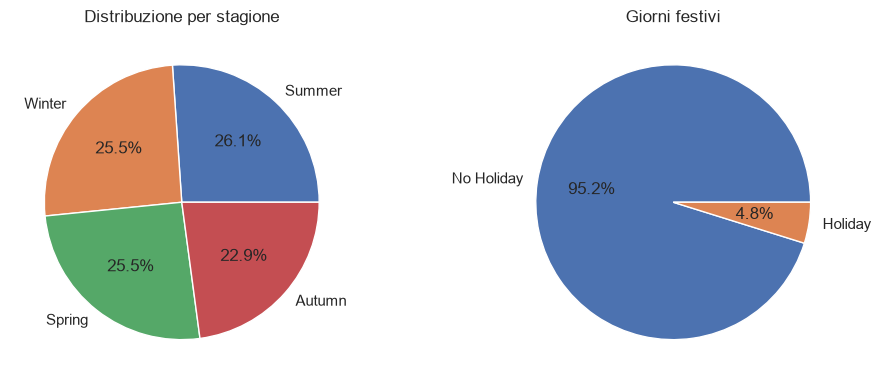

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df["season"].value_counts().plot.pie(autopct="%1.1f%%", ylabel="", ax=axes[0],
                                     title="Distribuzione per stagione")
df["holiday"].value_counts().plot.pie(autopct="%1.1f%%", ylabel="", ax=axes[1],
                                      title="Giorni festivi")
plt.tight_layout()
plt.show()

Le quattro stagioni sono **bilanciate** (≈25% ciascuna, con piccole differenze dovute alle ore di chiusura rimosse), mentre i giorni festivi rappresentano solo il 5% circa delle osservazioni — uno sbilanciamento naturale di cui non serve "correggere" nulla, trattandosi di una variabile predittiva e non del target.

### Distribuzione della variabile target

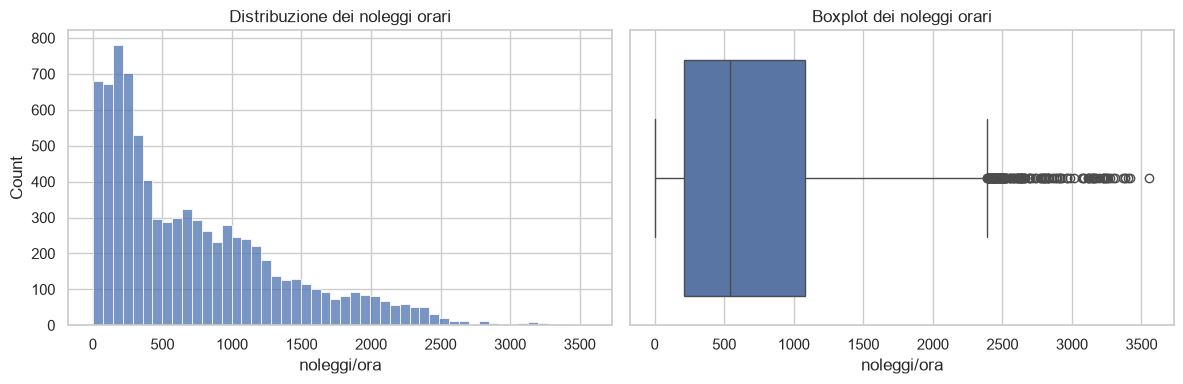

Skewness: 1.14


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["count"], bins=50, ax=axes[0])
axes[0].set(title="Distribuzione dei noleggi orari", xlabel="noleggi/ora")
sns.boxplot(x=df["count"], ax=axes[1])
axes[1].set(title="Boxplot dei noleggi orari", xlabel="noleggi/ora")
plt.tight_layout()
plt.show()
print("Skewness:", round(df["count"].skew(), 3))

La distribuzione del target conferma una **forte asimmetria positiva** (skewness ≈ 1,14): la maggior parte delle ore ha una domanda sotto i 1.000 noleggi, con una coda di ore di punta che arriva oltre 3.500. Questo ha due conseguenze pratiche:

1. i modelli addestrati minimizzando l'errore quadratico saranno dominati dalle ore di punta (gli errori grandi pesano quadraticamente);
2. può valere la pena provare una **trasformazione logaritmica del target** per i modelli lineari, che valuteremo nella fase di modellazione.

I valori estremi del boxplot non sono outlier da rimuovere: sono le ore di punta reali, esattamente ciò che il modello deve saper prevedere.

### Andamento temporale nell'anno

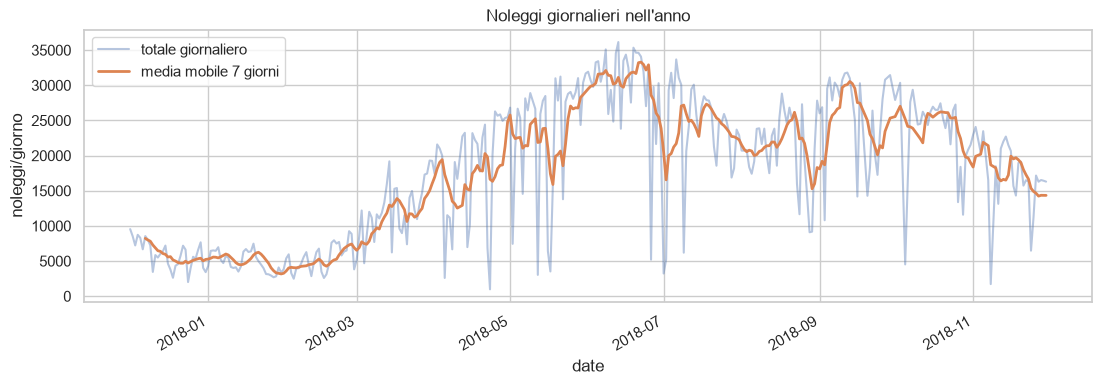

In [10]:
daily = df.groupby("date")["count"].sum()
plt.figure(figsize=(13, 4))
daily.plot(alpha=0.4, label="totale giornaliero")
daily.rolling(7).mean().plot(linewidth=2, label="media mobile 7 giorni")
plt.title("Noleggi giornalieri nell'anno")
plt.ylabel("noleggi/giorno")
plt.legend()
plt.show()

La serie giornaliera mostra una **stagionalità molto marcata**: la domanda crolla nei mesi invernali (dicembre–febbraio), cresce in primavera fino al picco di inizio estate e cala vistosamente a luglio–agosto, in corrispondenza della stagione delle piogge coreana (*jangma*) e del caldo umido estivo, per poi riprendersi in autunno. È un primo indizio che **stagione e meteo saranno predittori importanti**.

### Profilo orario: giorni lavorativi, weekend e stagioni

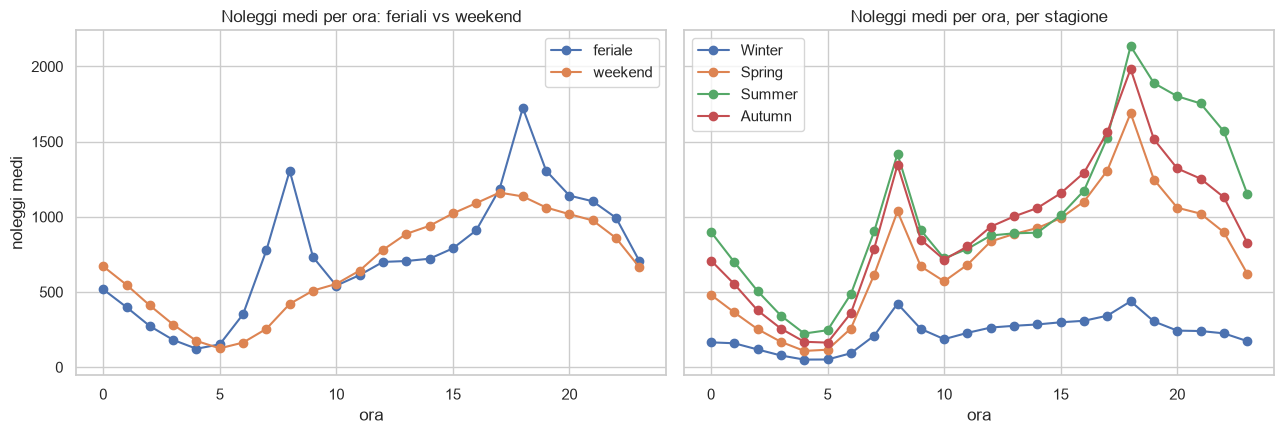

In [11]:
df["weekday"] = df["date"].dt.dayofweek          # 0 = lunedì ... 6 = domenica
df["weekend"] = (df["weekday"] >= 5)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for wk, label in [(False, "feriale"), (True, "weekend")]:
    prof = df[df["weekend"] == wk].groupby("hour")["count"].mean()
    axes[0].plot(prof.index, prof.values, marker="o", label=label)
axes[0].set(title="Noleggi medi per ora: feriali vs weekend", xlabel="ora", ylabel="noleggi medi")
axes[0].legend()

for s in ["Winter", "Spring", "Summer", "Autumn"]:
    prof = df[df["season"] == s].groupby("hour")["count"].mean()
    axes[1].plot(prof.index, prof.values, marker="o", label=s)
axes[1].set(title="Noleggi medi per ora, per stagione", xlabel="ora")
axes[1].legend()
plt.tight_layout()
plt.show()

Il profilo orario è il pattern più caratteristico del dataset:

- nei **giorni feriali** la curva è bimodale, con due picchi netti alle **8** e alle **18** — gli orari di pendolarismo casa-lavoro;
- nel **weekend** i picchi da pendolari spariscono e la domanda si distribuisce in una gobba unica nel pomeriggio;
- il pattern orario mantiene la stessa forma in tutte le stagioni ma con ampiezza molto diversa (l'inverno "schiaccia" la curva).

Questa è un'osservazione importante per la scelta dei modelli: l'effetto dell'ora **dipende** dal tipo di giorno (interazione ora × giorno della settimana) e dalla stagione. Un modello lineare semplice, che somma effetti indipendenti, non può catturare queste interazioni: ci aspettiamo quindi che regressione polinomiale e modelli ad albero (che catturano interazioni in modo naturale) abbiano un vantaggio.

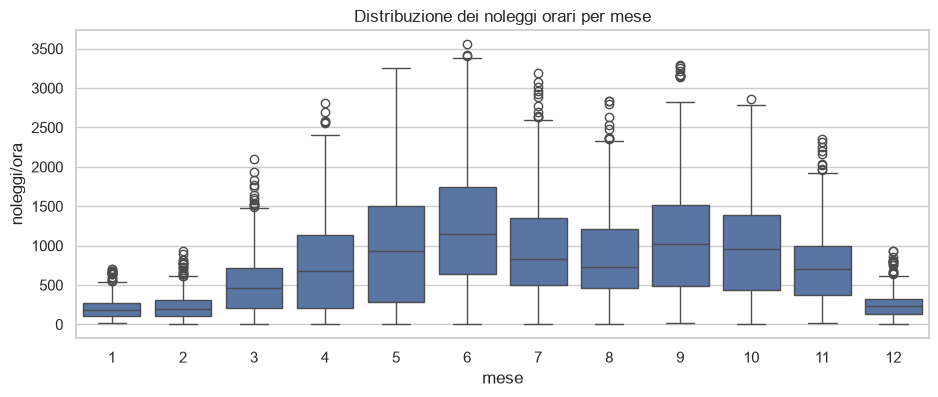

In [12]:
plt.figure(figsize=(11, 4))
sns.boxplot(data=df, x=df["date"].dt.month, y="count", color="#4c72b0")
plt.title("Distribuzione dei noleggi orari per mese")
plt.xlabel("mese")
plt.ylabel("noleggi/ora")
plt.show()

Il boxplot per mese conferma quanto visto sulla serie giornaliera: mediane basse e poco disperse nei mesi invernali (dicembre–febbraio), domanda alta e molto variabile da maggio a ottobre, con il calo di luglio–agosto. Il **mese** porta quindi informazione aggiuntiva rispetto alla sola stagione (ad es. giugno e agosto sono entrambi estivi ma molto diversi): per questo lo estrarremo dalla data come nuova variabile.

### Distribuzione delle variabili meteorologiche

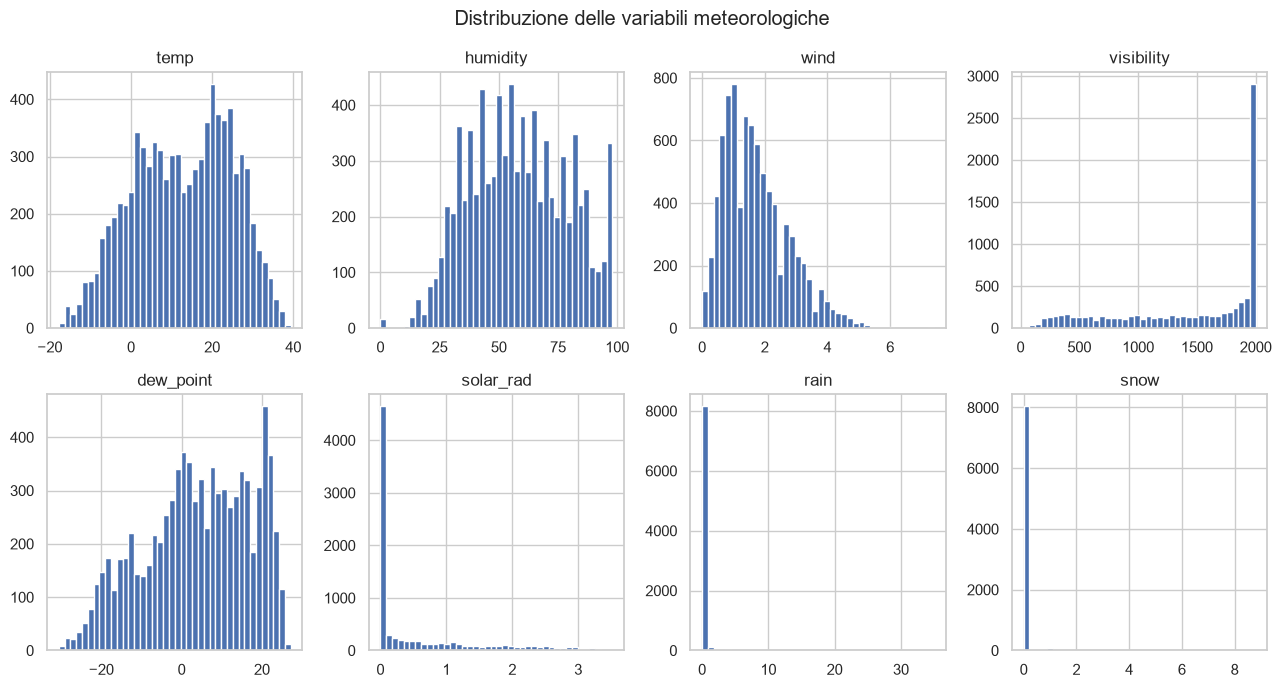

In [13]:
meteo = ["temp", "humidity", "wind", "visibility", "dew_point", "solar_rad", "rain", "snow"]
df[meteo].hist(bins=40, figsize=(13, 7), layout=(2, 4))
plt.suptitle("Distribuzione delle variabili meteorologiche")
plt.tight_layout()
plt.show()

Temperatura e punto di rugiada hanno distribuzioni ampie e plurimodali (riflettono le stagioni); l'umidità è ben distribuita; vento e radiazione solare sono asimmetriche; `visibility` è fortemente concentrata sul valore massimo di saturazione 2000; `rain` e `snow`, come anticipato, sono quasi sempre zero. Per pioggia e neve la rappresentazione in millimetri/centimetri è poco informativa di per sé: creeremo le variabili binarie `has_rain` e `has_snow`.

### Relazione tra meteo e domanda

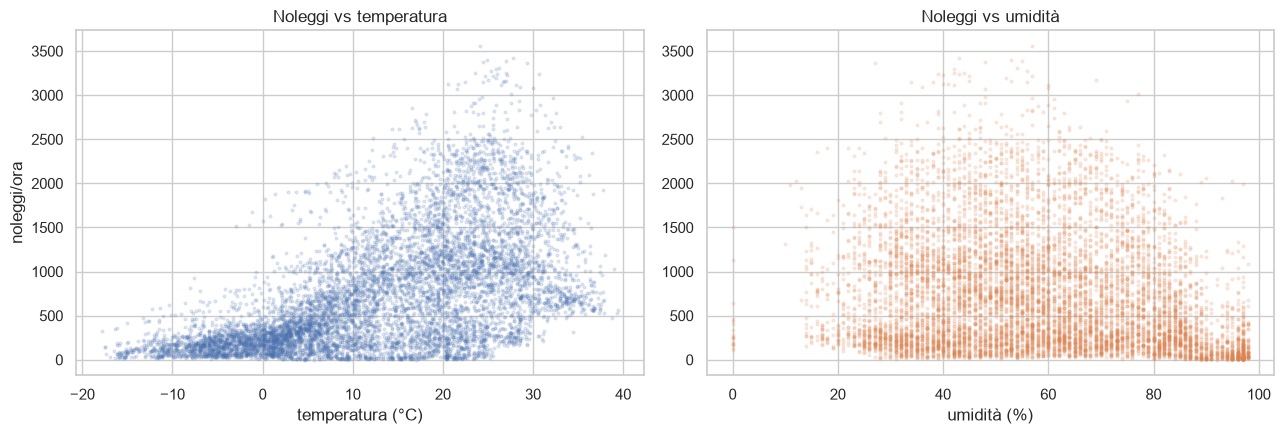

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(df["temp"], df["count"], s=4, alpha=0.15)
axes[0].set(title="Noleggi vs temperatura", xlabel="temperatura (°C)", ylabel="noleggi/ora")
axes[1].scatter(df["humidity"], df["count"], s=4, alpha=0.15, color="#dd8452")
axes[1].set(title="Noleggi vs umidità", xlabel="umidità (%)")
plt.tight_layout()
plt.show()

La relazione tra **temperatura** e noleggi è chiaramente **positiva ma non lineare**: la domanda cresce fino a ~25–30 °C e tende a ridursi alle temperature più estreme (troppo caldo scoraggia l'uso della bici quasi quanto il freddo). L'umidità mostra una relazione negativa più debole e rumorosa. Anche questo suggerisce che modelli capaci di catturare non linearità avranno un vantaggio.

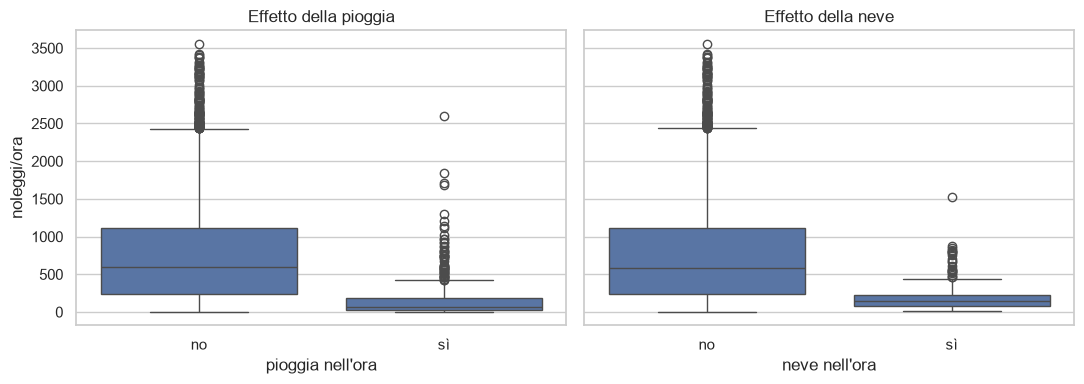

        mean  median
rain                
False  765.6   591.0
True   167.3    71.0


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
sns.boxplot(x=df["rain"] > 0, y=df["count"], ax=axes[0])
axes[0].set(title="Effetto della pioggia", xlabel="pioggia nell'ora", ylabel="noleggi/ora")
axes[0].set_xticks([0, 1], ["no", "sì"])
sns.boxplot(x=df["snow"] > 0, y=df["count"], ax=axes[1])
axes[1].set(title="Effetto della neve", xlabel="neve nell'ora")
axes[1].set_xticks([0, 1], ["no", "sì"])
plt.tight_layout()
plt.show()
print(df.groupby(df["rain"] > 0)["count"].agg(["mean", "median"]).round(1))

L'effetto della pioggia è **drastico**: nelle ore piovose la mediana dei noleggi crolla di quasi il 90% (da 591 a 71) e la media di quasi l'80%. Lo stesso vale per la neve. Si noti che la correlazione lineare di `rain` col target è bassa (≈ −0,13, come vedremo sotto) proprio perché l'effetto è **a soglia** e non proporzionale ai millimetri: un buon esempio di come il solo coefficiente di correlazione possa sottostimare l'importanza di una variabile.

### Correlazioni

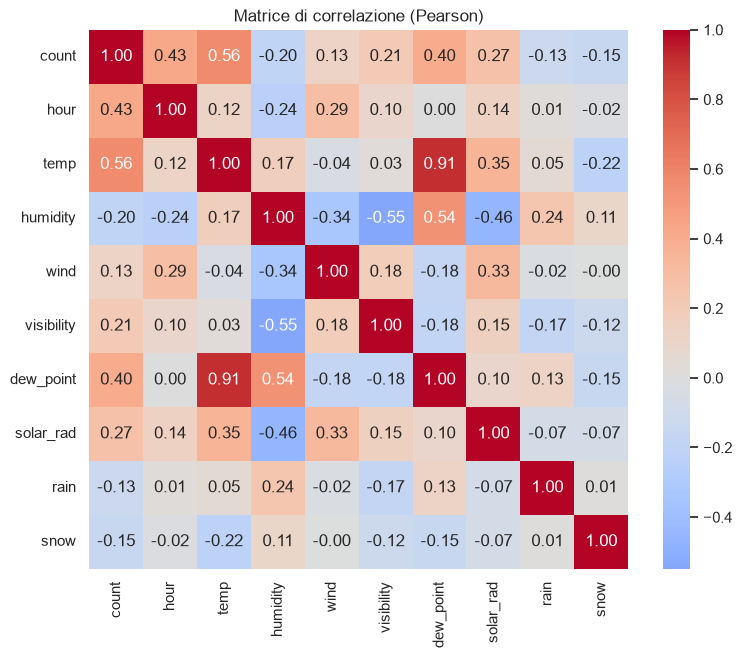

In [16]:
plt.figure(figsize=(9, 7))
corr = df[["count", "hour"] + meteo].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Matrice di correlazione (Pearson)")
plt.show()

Dalla matrice di correlazione:

- i predittori numerici più correlati col target sono **temperatura (0,56)**, **ora (0,43)** e punto di rugiada (0,40), seguiti dalla radiazione solare; umidità, neve e pioggia hanno correlazione negativa;
- **`dew_point` è quasi collineare con `temp` (0,91)** ed è fortemente legato anche all'umidità: di fatto il punto di rugiada è una funzione di temperatura e umidità. È un caso classico di **multicollinearità**: per i modelli lineari questo rende instabili i coefficienti delle variabili coinvolte. Decidiamo comunque di tenere la variabile (la regolarizzazione di Ridge/Lasso mitiga il problema e i modelli ad albero ne sono poco sensibili), ma ne terremo conto nell'interpretare i coefficienti;
- l'umidità è correlata negativamente con visibilità e radiazione solare, coerentemente con l'intuizione (aria umida → foschia).

## 3. Preparazione dei dati

### Generazione di nuove variabili

Dalla data estraiamo **mese** e **giorno della settimana** (già calcolato per l'EDA), che come visto portano informazione predittiva. Aggiungiamo inoltre le variabili binarie **`has_rain`** e **`has_snow`**, che catturano l'effetto a soglia di pioggia e neve osservato nell'analisi esplorativa.

Non includiamo invece la variabile `weekend` tra i predittori: è una combinazione esatta dei dummy del giorno della settimana (weekend = sabato + domenica) e creerebbe collinearità perfetta senza aggiungere informazione.

In [17]:
dati = df.copy()
dati["month"] = dati["date"].dt.month
dati["has_rain"] = (dati["rain"] > 0).astype(int)
dati["has_snow"] = (dati["snow"] > 0).astype(int)
dati["holiday"] = (dati["holiday"] == "Holiday").astype(int)
dati = dati.drop(columns=["date", "weekend"])
dati.head()

,count,hour,temp,humidity,wind,visibility,dew_point,solar_rad,rain,snow,season,holiday,weekday,month,has_rain,has_snow
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,0,4,12,0,0
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,0,4,12,0,0
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,0,4,12,0,0
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,0,4,12,0,0
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,0,4,12,0,0


### Codifica one-hot delle variabili categoriche

`season` è categorica nominale, mentre `hour`, `month` e `weekday` sono formalmente numeri ma **non hanno una relazione d'ordine lineare col target** (il profilo orario è bimodale, i mesi sono ciclici): trattarli come numeri costringerebbe i modelli lineari a una relazione monotona irrealistica. Li codifichiamo quindi tutti con **one-hot encoding**, usando `drop_first=True` per evitare la trappola delle variabili dummy (ogni gruppo di dummy sommerebbe a 1, creando collinearità perfetta con l'intercetta).

In [18]:
dati = pd.get_dummies(dati, columns=["hour", "month", "weekday", "season"],
                      drop_first=True, dtype=int)
print("Dimensioni della matrice dei dati:", dati.shape)

Dimensioni della matrice dei dati: (8465, 55)


### Separazione di target e predittori e suddivisione train/test

Isoliamo la variabile target `count` dalle variabili predittive e suddividiamo i dati in **training set (75%)** e **test set (25%)** con estrazione casuale (seed fissato per riproducibilità).

Una scelta metodologica importante: il test set verrà usato **solo per la valutazione finale** dei modelli. Tutte le scelte di modello e la ricerca degli iperparametri (sezione 5) verranno fatte con **cross validation all'interno del training set**, in modo da non "consumare" il test set e ottenere una stima finale non distorta.

In [19]:
from sklearn.model_selection import train_test_split

X = dati.drop(columns="count")
y = dati["count"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE)

print(f"Training set: {X_train.shape[0]} istanze — Test set: {X_test.shape[0]} istanze")
print(f"Variabili predittive: {X_train.shape[1]}")

Training set: 6348 istanze — Test set: 2117 istanze
Variabili predittive: 54


### Misure di valutazione

Per valutare i modelli di regressione usiamo le misure viste nel corso:

- **MSE** (errore quadratico medio) e la sua radice **RMSE**, espressa nella stessa unità del target (noleggi/ora);
- **MAE** (errore assoluto medio);
- **errore relativo medio (MAPE)** — da interpretare con cautela qui, perché le ore notturne con pochissimi noleggi (minimo 2) gonfiano gli errori percentuali;
- **coefficiente di determinazione R²**.

Definiamo una funzione che calcola le misure su training e test set, salvando i risultati sul test per il confronto finale.

In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

risultati = {}   # nome modello -> metriche sul test set

def valuta(modello, nome, salva=True):
    righe = {}
    for insieme, X_, y_ in [("training set", X_train, y_train), ("test set", X_test, y_test)]:
        pred = modello.predict(X_)
        righe[insieme] = {
            "MSE": mean_squared_error(y_, pred),
            "RMSE": np.sqrt(mean_squared_error(y_, pred)),
            "MAE": mean_absolute_error(y_, pred),
            "Err. relativo": np.mean(np.abs((pred - y_) / y_)),
            "R²": r2_score(y_, pred),
        }
    tab = pd.DataFrame(righe).T
    if salva:
        risultati[nome] = tab.loc["test set"]
    return tab.round(3)

### Modello di riferimento (baseline)

Prima di addestrare veri modelli, fissiamo un punto di riferimento con un regressore banale che predice sempre la **media** del training set: qualunque modello utile deve fare significativamente meglio.

In [21]:
from sklearn.dummy import DummyRegressor

baseline = DummyRegressor(strategy="mean").fit(X_train, y_train)
valuta(baseline, "Baseline (media)")

,MSE,RMSE,MAE,Err. relativo,R²
training set,410898.180,641.013,516.900,3.378,0.0
test set,417592.462,646.214,523.631,3.646,-0.0


Come atteso, il baseline ha **R² ≈ 0** (per costruzione non spiega alcuna varianza) e un RMSE pari alla deviazione standard del target (~640 noleggi). L'errore relativo enorme è dovuto alle ore notturne: predire ~730 noleggi quando quelli reali sono 5 produce un errore percentuale gigantesco.

## 4. Addestramento e validazione dei modelli

### 4.1 Regressione lineare

Partiamo dal modello più semplice e interpretabile: la **regressione lineare multipla** su tutte le variabili. Standardizziamo prima le variabili (media 0, varianza 1) tramite una pipeline: per la regressione lineare pura non è indispensabile, ma rende i **coefficienti confrontabili tra loro** e sarà necessaria per i modelli regolarizzati che seguono.

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

lin = Pipeline([("scaler", StandardScaler()), ("lr", LinearRegression())])
lin.fit(X_train, y_train)
valuta(lin, "Regressione lineare")

,MSE,RMSE,MAE,Err. relativo,R²
training set,113786.020,337.322,257.701,1.578,0.723
test set,117394.709,342.629,260.209,1.673,0.719


In [23]:
# R² aggiustato sul test set: corregge R² per il numero di variabili
def r2_aggiustato(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

r2_test = r2_score(y_test, lin.predict(X_test))
print(f"R² sul test set:        {r2_test:.4f}")
print(f"R² aggiustato sul test: {r2_aggiustato(r2_test, len(y_test), X.shape[1]):.4f}")

R² sul test set:        0.7188
R² aggiustato sul test: 0.7114


Il modello lineare spiega già una buona parte della varianza, con valori di R² **molto simili tra training e test set**: non c'è overfitting (abbiamo ~5.900 istanze di training contro ~50 variabili) e l'R² aggiustato è praticamente identico all'R², segno che il numero di variabili non sta gonfiando artificialmente il punteggio. Il limite del modello è semmai di **bias**: come visto nell'EDA, le interazioni ora × giorno e le non linearità della temperatura non sono rappresentabili da una somma di effetti indipendenti.

Analizziamo i coefficienti per individuare le variabili più rilevanti (essendo le variabili standardizzate, i valori assoluti sono confrontabili).

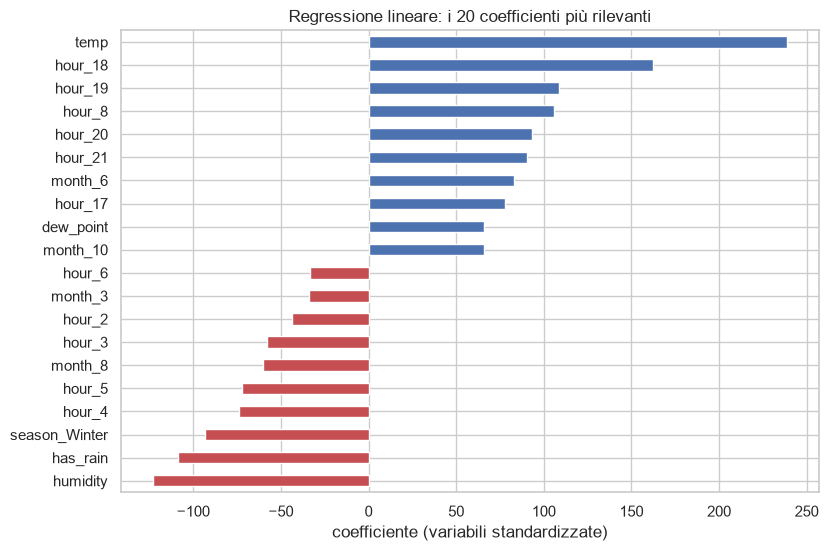

In [24]:
coef = pd.Series(lin["lr"].coef_, index=X.columns).sort_values()
top = pd.concat([coef.head(10), coef.tail(10)])
plt.figure(figsize=(9, 6))
top.plot.barh(color=np.where(top > 0, "#4c72b0", "#c44e52"))
plt.title("Regressione lineare: i 20 coefficienti più rilevanti")
plt.xlabel("coefficiente (variabili standardizzate)")
plt.show()

I coefficienti raccontano una storia coerente con l'analisi esplorativa: la **temperatura** ha il coefficiente positivo più alto, seguita dai dummy delle **ore di punta (17–21 e 8)** e dai mesi della bella stagione (giugno, ottobre); spingono invece verso il basso la domanda l'**umidità**, la **pioggia** (`has_rain`), l'**inverno** e le ore notturne/del primo mattino. Un dettaglio interessante è il segno negativo di `month_8` (agosto): è il mese del caldo umido e delle piogge monsoniche già notato nell'EDA. Compare tra i coefficienti più alti anche `dew_point`, ma — come discusso nell'EDA — i coefficienti delle variabili collineari vanno letti con molta prudenza: con temperatura e umidità nel modello, quel valore riflette più l'instabilità numerica della stima che un reale effetto causale.

### 4.2 Regressione lineare con trasformazione logaritmica del target

La distribuzione del target è fortemente asimmetrica e l'errore quadratico è dominato dalle ore di punta. Proviamo ad addestrare lo stesso modello su **log(1+y)**: il modello impara su una scala più simmetrica e gli errori relativi vengono pesati in modo più uniforme. `TransformedTargetRegressor` applica la trasformazione in addestramento e la inverte automaticamente in predizione, così le metriche restano confrontabili (sono calcolate sulla scala originale).

In [25]:
from sklearn.compose import TransformedTargetRegressor

lin_log = TransformedTargetRegressor(
    regressor=Pipeline([("scaler", StandardScaler()), ("lr", LinearRegression())]),
    func=np.log1p, inverse_func=np.expm1)
lin_log.fit(X_train, y_train)
valuta(lin_log, "Reg. lineare (target log)")

,MSE,RMSE,MAE,Err. relativo,R²
training set,97224.115,311.808,201.483,0.522,0.763
test set,97222.676,311.806,202.785,0.532,0.767


La trasformazione migliora il modello lineare su **tutte** le misure: l'errore relativo crolla da ~170% a ~53% (il modello non commette più errori percentuali assurdi sulle ore notturne) e anche R² sale di quasi 5 punti. Il risultato suggerisce che la relazione tra predittori e domanda è più vicina a **moltiplicativa** che additiva (ad es. la pioggia "dimezza" la domanda invece di sottrarre un numero fisso di noleggi), e sulla scala logaritmica questi effetti diventano additivi, cioè proprio ciò che un modello lineare sa rappresentare. Nel seguito manteniamo comunque il target sulla scala originale, per confrontare tutti i modelli in modo omogeneo sulle stesse metriche.

### 4.3 Regressione regolarizzata: Ridge e Lasso

Applichiamo ora la regolarizzazione L2 (**Ridge**) e L1 (**Lasso**). Con un rapporto istanze/variabili così favorevole non ci aspettiamo grandi guadagni di performance; l'interesse è soprattutto per la **stabilità dei coefficienti** in presenza di collinearità (Ridge) e per la **selezione automatica delle variabili** (Lasso, che azzera i coefficienti meno utili). Il valore di α qui è fissato a 5; lo ottimizzeremo con la grid search nella sezione 5.

In [26]:
from sklearn.linear_model import Ridge, Lasso

ridge = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=5))])
ridge.fit(X_train, y_train)
valuta(ridge, "Ridge (α=5)")

,MSE,RMSE,MAE,Err. relativo,R²
training set,113786.784,337.323,257.663,1.576,0.723
test set,117411.526,342.654,260.216,1.673,0.719


In [27]:
lasso = Pipeline([("scaler", StandardScaler()), ("lasso", Lasso(alpha=5, max_iter=10000))])
lasso.fit(X_train, y_train)
valuta(lasso, "Lasso (α=5)")

,MSE,RMSE,MAE,Err. relativo,R²
training set,115226.330,339.450,257.580,1.502,0.720
test set,118886.049,344.799,260.379,1.605,0.715


In [28]:
coef_lasso = pd.Series(lasso["lasso"].coef_, index=X.columns)
azzerate = coef_lasso[coef_lasso == 0].index.tolist()
print(f"Variabili azzerate dal Lasso: {len(azzerate)} su {len(coef_lasso)}")
print(azzerate)

Variabili azzerate dal Lasso: 9 su 54
['wind', 'dew_point', 'solar_rad', 'snow', 'hour_15', 'month_4', 'weekday_1', 'season_Spring', 'season_Summer']


Come previsto le performance restano in linea con la regressione lineare semplice. Interessante però la selezione operata dal **Lasso**: vengono azzerate le variabili meteo più deboli (vento, neve, radiazione solare) e proprio `dew_point` — confermando che, note temperatura e umidità, il punto di rugiada non aggiunge quasi nulla — insieme ad alcuni dummy "intermedi" di ore, mesi e stagioni, il cui effetto non si distingue dalla categoria di riferimento. Il Lasso ci dà quindi gratis un'analisi di rilevanza delle variabili coerente con quanto osservato finora.

### 4.4 Regressione polinomiale

Per catturare **interazioni e non linearità** restando nella famiglia dei modelli lineari, generiamo le variabili polinomiali di grado 2 (tutti i prodotti tra coppie di variabili, ad es. `temp × season_Winter` o `hour_18 × weekday_5`) e applichiamo una regressione **Ridge**: con ~1.500 variabili generate la regolarizzazione diventa indispensabile per controllare l'overfitting.

In [29]:
from sklearn.preprocessing import PolynomialFeatures

poly = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=10)),
])
poly.fit(X_train, y_train)
print("Variabili dopo l'espansione polinomiale:",
      poly["poly"].n_output_features_)
valuta(poly, "Polinomiale gr.2 + Ridge")

Variabili dopo l'espansione polinomiale: 1539


,MSE,RMSE,MAE,Err. relativo,R²
training set,27508.544,165.857,110.781,0.587,0.933
test set,49003.768,221.368,135.971,0.994,0.883


Il salto di qualità è netto: le interazioni catturate dal polinomio (l'effetto dell'ora che cambia tra feriale e weekend, la temperatura che pesa diversamente per stagione) valgono **oltre 16 punti di R²** rispetto al modello lineare semplice (da 0,72 a 0,88). Compare un po' di divario tra training e test (0,93 contro 0,88), ma la regolarizzazione lo tiene sotto controllo.

### 4.5 Albero di regressione

Passiamo ai modelli ad albero, che catturano interazioni e non linearità in modo nativo partizionando ricorsivamente lo spazio. Per prima cosa vediamo cosa succede con un albero **senza vincoli di crescita**.

In [30]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

albero_pieno = DecisionTreeRegressor(random_state=RANDOM_STATE)
albero_pieno.fit(X_train, y_train)
valuta(albero_pieno, nome="", salva=False)

,MSE,RMSE,MAE,Err. relativo,R²
training set,0.000,0.000,0.000,0.000,1.000
test set,74309.064,272.597,156.973,0.553,0.822


L'albero senza vincoli ha **errore nullo sul training set** (ogni foglia contiene di fatto una singola istanza) e perde quasi 20 punti di R² sul test: il divario training/test è il sintomo da manuale dell'**overfitting**. Proviamo a limitare la complessità con una profondità massima e un numero minimo di istanze per foglia — vedremo che anche l'eccesso opposto ha un costo.

In [31]:
albero = DecisionTreeRegressor(max_depth=7, min_samples_leaf=5, random_state=RANDOM_STATE)
albero.fit(X_train, y_train)
valuta(albero, "Albero di regressione")

,MSE,RMSE,MAE,Err. relativo,R²
training set,116348.421,341.099,235.940,0.844,0.717
test set,131607.824,362.778,254.558,0.968,0.685


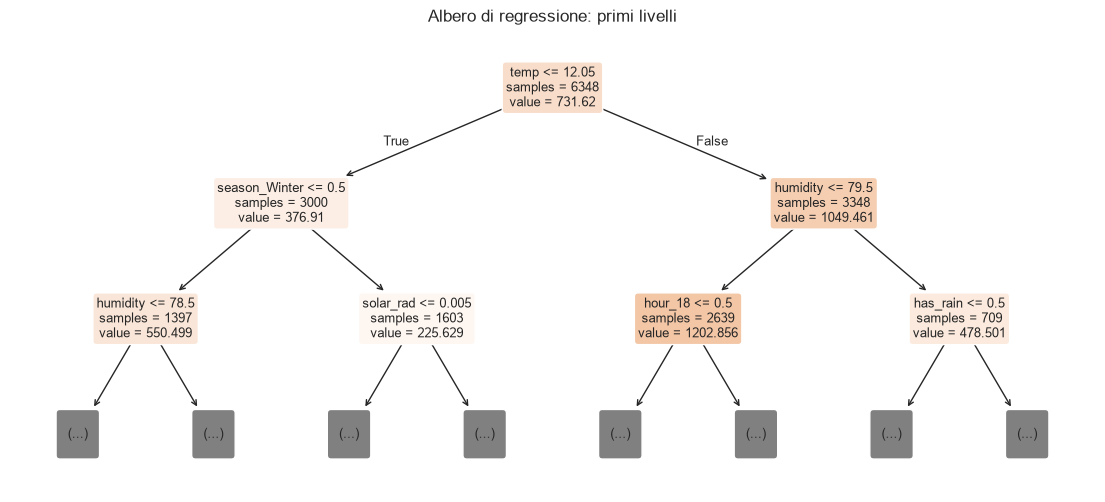

In [32]:
plt.figure(figsize=(14, 6))
plot_tree(albero, max_depth=2, feature_names=X.columns, filled=True,
          fontsize=9, rounded=True, impurity=False)
plt.title("Albero di regressione: primi livelli")
plt.show()

Vincolato così, l'albero ha in realtà **più bias che varianza**: sul test va *peggio* dell'albero pieno (0,69 contro 0,82), segno che la potatura scelta a mano è troppo aggressiva. Il giusto equilibrio lo cercheremo con la grid search nella sezione 5; intanto questo albero compatto è prezioso per l'**interpretazione**.

I primi livelli sono infatti molto leggibili e confermano la gerarchia di importanza delle variabili: la radice divide sulla **temperatura** (sopra/sotto ~12 °C), al secondo livello compaiono l'**inverno** e l'**umidità**, e subito sotto l'**ora di punta delle 18**, la **pioggia** e la radiazione solare. L'albero "riscopre" da solo la struttura individuata nell'EDA: prima il clima, poi il momento della giornata.

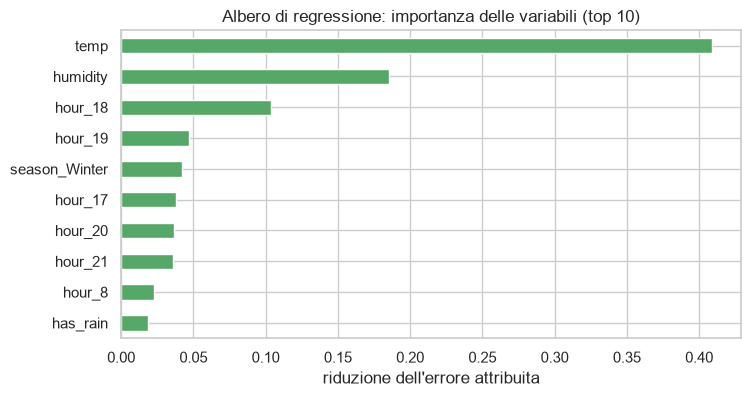

In [33]:
imp = pd.Series(albero.feature_importances_, index=X.columns).nlargest(10)
imp.sort_values().plot.barh(figsize=(8, 4), color="#55a868")
plt.title("Albero di regressione: importanza delle variabili (top 10)")
plt.xlabel("riduzione dell'errore attribuita")
plt.show()

### 4.6 Random Forest

Una **foresta casuale** combina molti alberi addestrati su sottoinsiemi casuali di istanze e variabili (bagging), riducendo la varianza del singolo albero.

In [34]:
from sklearn.ensemble import RandomForestRegressor

foresta = RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE)
foresta.fit(X_train, y_train)
valuta(foresta, "Random Forest")

,MSE,RMSE,MAE,Err. relativo,R²
training set,5451.198,73.832,45.165,0.179,0.987
test set,39367.575,198.413,121.964,0.524,0.906


La foresta migliora nettamente il singolo albero: l'aggregazione di 300 alberi riduce la varianza e produce un R² sul test ben più alto, pur mantenendo un certo overfitting "fisiologico" sul training (gli alberi della foresta crescono in profondità per costruzione).

### 4.7 XGBoost

Infine il **gradient boosting** con la libreria XGBoost: gli alberi vengono costruiti **in sequenza**, ciascuno addestrato sui residui del modello precedente, con regolarizzazione esplicita sulla complessità degli alberi. Usiamo per ora iperparametri standard prudenti; l'ottimizzazione vera arriva nella sezione 5.

In [35]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=400, learning_rate=0.08, max_depth=6,
                   tree_method="hist", random_state=RANDOM_STATE, n_jobs=-1)
xgb.fit(X_train, y_train)
valuta(xgb, "XGBoost")

,MSE,RMSE,MAE,Err. relativo,R²
training set,6147.183,78.404,51.060,0.200,0.985
test set,28511.564,168.854,107.694,0.456,0.932


XGBoost è il migliore tra i modelli provati finora, come spesso accade sui dati tabellari: il boosting corregge iterativamente gli errori residui e la regolarizzazione interna tiene sotto controllo la complessità.

## 5. Ricerca degli iperparametri

Ottimizziamo ora gli iperparametri dei tre modelli più promettenti di famiglie diverse. Tutte le ricerche usano la **5-fold cross validation sul solo training set** (scoring = R²): il test set resta intatto per la valutazione finale.

### 5.1 Grid search: regressione polinomiale con Ridge

Per il modello polinomiale ottimizziamo congiuntamente il **grado del polinomio** e il **coefficiente di regolarizzazione α** con una ricerca esaustiva.

In [36]:
from sklearn.model_selection import GridSearchCV

griglia_ridge = {
    "poly__degree": [1, 2],
    "ridge__alpha": [0.3, 3, 30, 300, 3000],
}
gs_ridge = GridSearchCV(poly, griglia_ridge, cv=5, n_jobs=-1)
gs_ridge.fit(X_train, y_train)

print("Migliori parametri:", gs_ridge.best_params_)
print(f"R² medio in cross validation: {gs_ridge.best_score_:.4f}")

Migliori parametri: {'poly__degree': 2, 'ridge__alpha': 30}
R² medio in cross validation: 0.8888


In [37]:
tab_gs = (pd.DataFrame(gs_ridge.cv_results_)
          .pivot_table(index="param_ridge__alpha", columns="param_poly__degree",
                       values="mean_test_score"))
tab_gs.round(4)

param_poly__degree,1,2
param_ridge__alpha,,
0.3,0.7162,0.8680
3.0,0.7163,0.8858
30.0,0.7165,0.8888
300.0,0.7150,0.8866
3000.0,0.6569,0.8603


In [38]:
valuta(gs_ridge.best_estimator_, "Ridge polinomiale (grid search)")

,MSE,RMSE,MAE,Err. relativo,R²
training set,28371.799,168.439,112.006,0.588,0.931
test set,46244.996,215.046,135.851,0.970,0.889


La tabella della griglia mostra chiaramente che il **grado 2 domina il grado 1** per qualunque α (le interazioni sono essenziali) e che entro il grado 2 la performance è poco sensibile ad α su un ampio intervallo (R² in CV tra 0,868 e 0,889 per α da 0,3 a 30): l'ottimo è **α=30**, mentre a α=3000 la penalizzazione diventa eccessiva e il punteggio cala (inizio di underfitting). Con ~1.500 variabili una regolarizzazione robusta è la scelta giusta.

### 5.2 Grid search: albero di regressione

Per l'albero ottimizziamo i due iperparametri che ne controllano la complessità: la **profondità massima** e il **numero minimo di istanze per foglia**.

In [39]:
griglia_albero = {
    "max_depth": [7, 9, 11, 13, None],
    "min_samples_leaf": [1, 4, 8, 16],
}
gs_albero = GridSearchCV(DecisionTreeRegressor(random_state=RANDOM_STATE),
                         griglia_albero, cv=5, n_jobs=-1)
gs_albero.fit(X_train, y_train)

print("Migliori parametri:", gs_albero.best_params_)
print(f"R² medio in cross validation: {gs_albero.best_score_:.4f}")

Migliori parametri: {'max_depth': None, 'min_samples_leaf': 4}
R² medio in cross validation: 0.8151


In [40]:
valuta(gs_albero.best_estimator_, "Albero (grid search)")

,MSE,RMSE,MAE,Err. relativo,R²
training set,19340.912,139.072,80.592,0.235,0.953
test set,71928.399,268.195,162.785,0.544,0.828


La cross validation sceglie un albero **senza limite di profondità** ma con almeno 4 istanze per foglia: una potatura molto più leggera del nostro tentativo manuale (profondità 7), che evidentemente toglieva più segnale di quanto rumore eliminasse. Il vincolo sulle foglie smussa l'overfitting dell'albero pieno (R² sul training scende da 1,00 a 0,95) e migliora leggermente il test (0,83 contro 0,82). Resta però evidente il tetto del singolo albero, ben sotto i modelli ensemble: la varianza si combatte meglio **aggregando molti alberi** (Random Forest, boosting) che potandone uno solo, come confermano le sezioni 4.6 e 4.7.

### 5.3 Randomized search: XGBoost

XGBoost ha molti iperparametri che interagiscono tra loro: una griglia esaustiva sarebbe enorme. Usiamo quindi una **ricerca a campione** (randomized search), che esplora 25 combinazioni estratte da distribuzioni di probabilità sugli iperparametri principali: numero di alberi, learning rate, profondità, sottocampionamento di istanze e variabili, regolarizzazione.

In [41]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform, loguniform

distribuzioni = {
    "n_estimators": randint(100, 600),
    "learning_rate": loguniform(0.01, 0.3),
    "max_depth": randint(3, 10),
    "subsample": uniform(0.6, 0.4),          # da 0.6 a 1.0
    "colsample_bytree": uniform(0.6, 0.4),   # da 0.6 a 1.0
    "min_child_weight": randint(1, 10),
    "reg_lambda": loguniform(0.1, 10),
}
rs_xgb = RandomizedSearchCV(
    XGBRegressor(tree_method="hist", random_state=RANDOM_STATE, n_jobs=1),
    distribuzioni, n_iter=25, cv=5, n_jobs=-1, random_state=RANDOM_STATE)
rs_xgb.fit(X_train, y_train)

print("Migliori parametri:", rs_xgb.best_params_)
print(f"R² medio in cross validation: {rs_xgb.best_score_:.4f}")

Migliori parametri: {'colsample_bytree': np.float64(0.9850914585077564), 'learning_rate': np.float64(0.16241864319205335), 'max_depth': 6, 'min_child_weight': 4, 'n_estimators': 558, 'reg_lambda': np.float64(1.4399731680888048), 'subsample': np.float64(0.8183984604143211)}
R² medio in cross validation: 0.9254


In [42]:
valuta(rs_xgb.best_estimator_, "XGBoost (randomized search)")

,MSE,RMSE,MAE,Err. relativo,R²
training set,659.121,25.673,18.362,0.080,0.998
test set,26488.016,162.751,103.457,0.425,0.937


La ricerca a campione migliora la configurazione iniziale (R² sul test da 0,932 a 0,937): un guadagno contenuto — segno che XGBoost era già vicino al suo massimo su questi dati — ottenuto con **più alberi (~560) e un learning rate più aggressivo (≈0,16)**, bilanciati dal sottocampionamento delle istanze (~0,82) e dal vincolo sul numero minimo di istanze per nodo. È un buon esempio di come in XGBoost contino gli equilibri tra iperparametri più che i singoli valori: configurazioni diverse possono raggiungere performance simili purché capacità e regolarizzazione si compensino.

### 5.4 Validazione approfondita: nested cross validation

Il punteggio di cross validation del modello scelto dalla ricerca è **leggermente ottimistico**: gli stessi fold usati per scegliere gli iperparametri vengono usati anche per valutarli. Per una stima non distorta dell'intera *procedura* (ricerca + addestramento) usiamo la **nested cross validation**: un ciclo esterno di valutazione, e in ogni fold esterno un ciclo interno che rifà da capo la ricerca degli iperparametri. Per contenere i tempi usiamo 3 fold esterni e una ricerca interna ridotta (10 combinazioni, 3 fold).

In [43]:
from sklearn.model_selection import cross_val_score, KFold

ricerca_interna = RandomizedSearchCV(
    XGBRegressor(tree_method="hist", random_state=RANDOM_STATE, n_jobs=1),
    distribuzioni, n_iter=10, cv=3, n_jobs=-1, random_state=RANDOM_STATE)

cv_esterna = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
punteggi = cross_val_score(ricerca_interna, X_train, y_train, cv=cv_esterna)

print("R² nei fold esterni:", np.round(punteggi, 4))
print(f"Stima nested CV: {punteggi.mean():.4f} ± {punteggi.std():.4f}")

R² nei fold esterni: [0.906  0.9204 0.9258]
Stima nested CV: 0.9174 ± 0.0083


La stima nested (R² ≈ 0,917 ± 0,008) è di poco inferiore al punteggio della randomized search (0,925), come atteso — quel punteggio è leggermente ottimistico per costruzione. Il valore osservato sul test set (0,937) è invece un po' più alto: è la normale variabilità di una singola suddivisione dei dati, ed è proprio il motivo per cui la nested CV, che media più suddivisioni e più ricerche indipendenti, fornisce la stima più prudente e affidabile della performance attesa su dati nuovi. Nel complesso la procedura di selezione **non sta sovradattando gli iperparametri**.

## 6. Confronto finale e conclusioni

### Confronto dei modelli sul test set

In [44]:
confronto = pd.DataFrame(risultati).T.sort_values("R²", ascending=False)
confronto.round(3)

,MSE,RMSE,MAE,Err. relativo,R²
XGBoost (randomized search),26488.016,162.751,103.457,0.425,0.937
XGBoost,28511.564,168.854,107.694,0.456,0.932
Random Forest,39367.575,198.413,121.964,0.524,0.906
Ridge polinomiale (grid search),46244.996,215.046,135.851,0.970,0.889
Polinomiale gr.2 + Ridge,49003.768,221.368,135.971,0.994,0.883
Albero (grid search),71928.399,268.195,162.785,0.544,0.828
Reg. lineare (target log),97222.676,311.806,202.785,0.532,0.767
Regressione lineare,117394.709,342.629,260.209,1.673,0.719
Ridge (α=5),117411.526,342.654,260.216,1.673,0.719
Lasso (α=5),118886.049,344.799,260.379,1.605,0.715


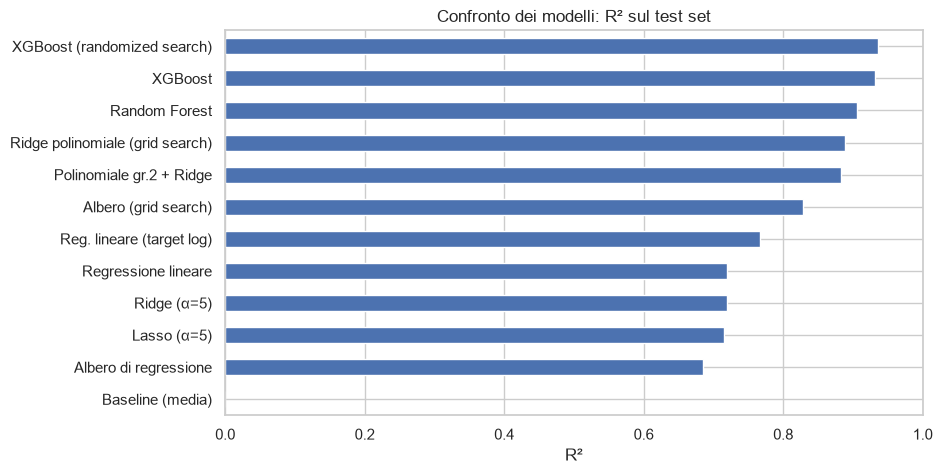

In [45]:
plt.figure(figsize=(9, 5))
confronto["R²"].sort_values().plot.barh(color="#4c72b0")
plt.title("Confronto dei modelli: R² sul test set")
plt.xlabel("R²")
plt.xlim(0, 1)
plt.show()

### Analisi del modello migliore

Esaminiamo più da vicino le predizioni del modello migliore (XGBoost ottimizzato).

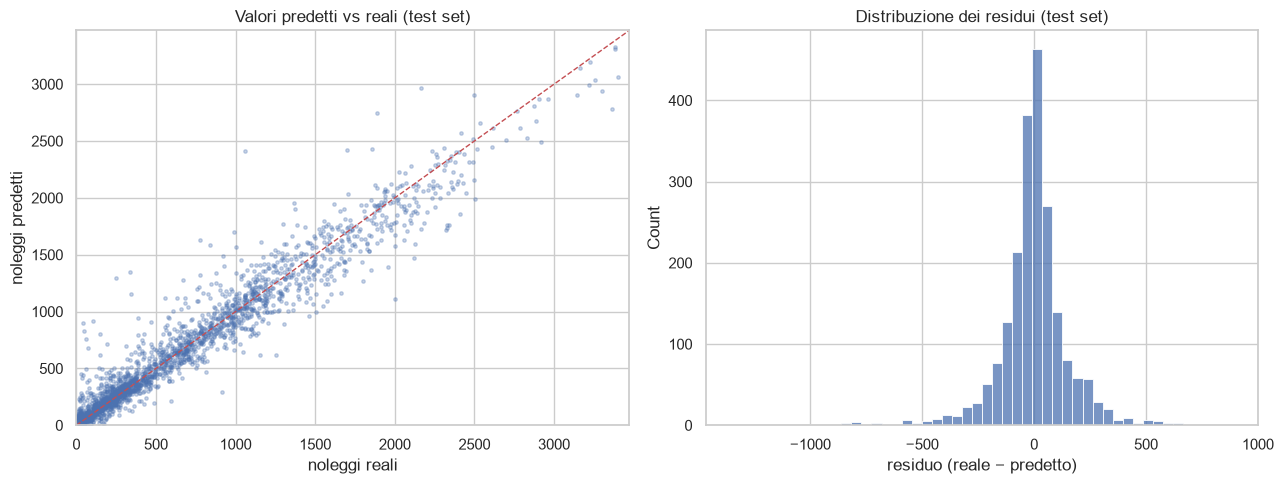

Media dei residui: -4.1 — Deviazione standard: 162.7


In [46]:
migliore = rs_xgb.best_estimator_
pred_test = migliore.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test, pred_test, s=6, alpha=0.3)
lim = [0, max(y_test.max(), pred_test.max()) * 1.02]
axes[0].plot(lim, lim, "r--", linewidth=1)
axes[0].set(title="Valori predetti vs reali (test set)", xlabel="noleggi reali",
            ylabel="noleggi predetti", xlim=lim, ylim=lim)

residui = y_test - pred_test
sns.histplot(residui, bins=50, ax=axes[1])
axes[1].set(title="Distribuzione dei residui (test set)", xlabel="residuo (reale − predetto)")
plt.tight_layout()
plt.show()
print(f"Media dei residui: {residui.mean():.1f} — Deviazione standard: {residui.std():.1f}")

Il grafico predetto-vs-reale mostra punti ben allineati sulla diagonale, con dispersione che cresce per i valori alti: gli errori maggiori si concentrano nelle ore di punta, dove la domanda è intrinsecamente più variabile. I residui sono centrati intorno allo zero e approssimativamente simmetrici, senza distorsioni sistematiche evidenti.

### Intervallo di confidenza del coefficiente R²

Calcoliamo infine l'intervallo di confidenza al 95% dell'R² del modello migliore sul test set, usando la formula della varianza dell'R² vista nel corso.

In [47]:
from scipy import stats

r2 = r2_score(y_test, pred_test)
n = len(y_test)           # istanze del test set
k = X_test.shape[1]       # variabili di input

VR = (4 * r2 * (1 - r2)**2 * (n - k - 1)**2) / ((n**2 - 1) * (n + 3))
t = stats.t.ppf(1 - 0.025, n)
print(f"R² = {r2:.4f} — intervallo di confidenza al 95%: "
      f"[{r2 - t*np.sqrt(VR):.4f}, {r2 + t*np.sqrt(VR):.4f}]")

R² = 0.9366 — intervallo di confidenza al 95%: [0.9315, 0.9416]


L'intervallo è stretto grazie alla numerosità del test set (~2.100 istanze): la stima dell'R² è affidabile.

### Le variabili più rilevanti

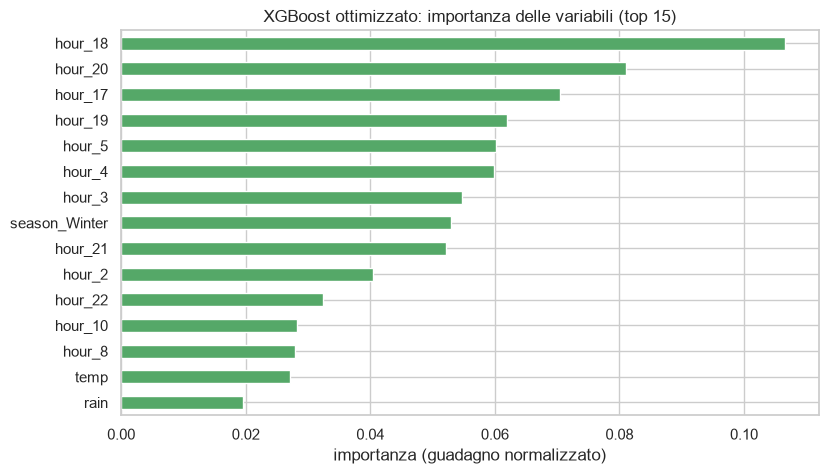

In [48]:
importanze = pd.Series(migliore.feature_importances_, index=X.columns).nlargest(15)
importanze.sort_values().plot.barh(figsize=(9, 5), color="#55a868")
plt.title("XGBoost ottimizzato: importanza delle variabili (top 15)")
plt.xlabel("importanza (guadagno normalizzato)")
plt.show()

Le variabili più importanti per il modello finale ricalcano quanto emerso dall'analisi esplorativa e dai modelli interpretabili (coefficienti della regressione, primi nodi dell'albero):

- i **dummy delle ore** dominano la classifica: in testa le ore di punta serali (`hour_18` su tutte, poi 17–21), seguite dalle ore notturne (2–5), che il modello usa per "spegnere" la domanda, e dalle 8 del mattino;
- tra le variabili non orarie spiccano l'**inverno** (`season_Winter`), la **temperatura** e la **pioggia**.

È interessante il confronto con la regressione lineare, dove la temperatura aveva il coefficiente più alto: per XGBoost l'informazione climatica è in parte già "contenuta" nello split sull'inverno e nelle interazioni tra alberi, mentre la struttura oraria — che il modello lineare può solo sommare e non incrociare col tipo di giorno — qui esprime tutto il suo valore predittivo.

### Conclusioni

Ripercorrendo il lavoro svolto:

1. abbiamo analizzato un anno di noleggi orari del bike sharing di Seoul, individuando pattern forti e interpretabili: doppio picco da pendolarismo nei feriali, forte stagionalità, effetto a soglia della pioggia, relazione non lineare con la temperatura;
2. l'analisi esplorativa ha guidato la preparazione dei dati: rimozione delle ore a servizio chiuso, estrazione di mese e giorno della settimana dalla data, creazione dei flag pioggia/neve, one-hot encoding delle variabili cicliche;
3. abbiamo addestrato e confrontato **dodici configurazioni di modelli** di complessità crescente, dal baseline alla regressione lineare (anche con target logaritmico, Ridge e Lasso), alla polinomiale, fino ad albero di regressione, Random Forest e XGBoost;
4. la ricerca degli iperparametri (grid search per i modelli lineari e l'albero, randomized search per XGBoost) e la nested cross validation hanno confermato la solidità dei risultati.

Il quadro finale è coerente: i modelli lineari semplici si fermano dove iniziano le interazioni (R² ≈ 0,72); aggiungere i termini polinomiali recupera gran parte del divario (≈ 0,89); i modelli ensemble ad albero, e **XGBoost ottimizzato in particolare**, offrono le prestazioni migliori, con un **R² sul test set di 0,937** (intervallo di confidenza al 95%: [0,93–0,94]) e un **RMSE di ~163 noleggi/ora** a fronte di una deviazione standard del target di ~640.

Possibili sviluppi futuri:

- **variabili autoregressive** (noleggi dell'ora/del giorno precedente): trattando il problema come serie temporale si potrebbe migliorare ulteriormente, al prezzo di un modello utilizzabile solo in previsione a brevissimo termine;
- in un impiego reale il meteo dell'ora da prevedere non è osservato ma **previsto**: andrebbe valutata la robustezza del modello all'errore delle previsioni meteo;
- il dataset copre **un solo anno**: non è possibile validare la generalizzazione ad anni diversi (trend di crescita del servizio, eventi eccezionali);
- esporre il modello tramite una semplice **applicazione web** che, dati ora e previsioni meteo, restituisca la domanda attesa.